In [1]:
import pandas as pd

In [59]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

!apt-get update -qq
!apt-get install fonts-nanum* -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings(action='ignore')

path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'  # 나눔 고딕
font_name = fm.FontProperties(fname=path, size=10).get_name()  # 기본 폰트 사이즈 : 10
plt.rc('font', family=font_name)

#음수 표현하는 코드 추가
plt.rcParams['axes.unicode_minus'] = False

fm.fontManager.addfont(path)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (36.9 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118252 files and direct

In [2]:
accounts_user = pd.read_csv('/content/drive/MyDrive/고급 프로젝트 DATA/accounts_user.csv')
polls_question = pd.read_csv('/content/drive/MyDrive/고급 프로젝트 DATA/polls_question.csv')
polls_questionpiece = pd.read_csv('/content/drive/MyDrive/고급 프로젝트 DATA/polls_questionpiece.csv')
polls_usercandidate = pd.read_csv('/content/drive/MyDrive/고급 프로젝트 DATA/polls_usercandidate.csv')

# 데이터 구조 파악

In [31]:
# step 1. 컬럼명 지정


# polls_questionpiece
polls_questionpiece.columns = [
    'id',
    'is_voted',
    'created_at',
    'question_id',
    'is_skipped'
]






# polls_question
polls_question.columns = [
    'id',
    'question_text',
    'created_at'
]


# polls_usercandidate
polls_usercandidate.columns = [
    'id',
    'created_at',
    'question_piece_id',
    'user_id'
]


# accounts_user
accounts_user.columns = [
    'id',
    'is_superuser',
    'is_staff',
    'gender',
    'point',
    'friend_id_list',
    'is_push_on',
    'created_at',
    'block_user_id_list',
    'hide_user_id_list',
    'ban_status',
    'report_count',
    'alarm_count',
    'pending_chat',
    'pending_votes',
    'group_id'
]

In [32]:
# STEP 2. 타입 변환

print(polls_question.dtypes)
print(polls_questionpiece.dtypes)
print(polls_usercandidate.dtypes)
print(accounts_user.dtypes)

id                        Int64
question_text            object
created_at       datetime64[ns]
dtype: object
id                      int64
is_voted                int64
created_at     datetime64[ns]
question_id             int64
is_skipped              int64
dtype: object
id                            int64
created_at           datetime64[ns]
question_piece_id             int64
user_id                       int64
dtype: object
id                             int64
is_superuser                   int64
is_staff                       int64
gender                        object
point                          int64
friend_id_list                object
is_push_on                     int64
created_at            datetime64[ns]
block_user_id_list            object
hide_user_id_list             object
ban_status                    object
report_count                   int64
alarm_count                    int64
pending_chat                   int64
pending_votes                  int64
group_id     

In [33]:
# STEP 3. 날짜 컬럼 datetime 변환

polls_question['created_at'] = pd.to_datetime(
    polls_question['created_at'],
    errors='coerce'
)

polls_questionpiece['created_at'] = pd.to_datetime(
    polls_questionpiece['created_at'],
    errors='coerce'
)

polls_usercandidate['created_at'] = pd.to_datetime(
    polls_usercandidate['created_at'],
    errors='coerce'
)

accounts_user['created_at'] = pd.to_datetime(
    accounts_user['created_at'],
    errors='coerce'
)

In [34]:
print(polls_question['created_at'].min(), polls_question['created_at'].max())
print(polls_questionpiece['created_at'].min(), polls_questionpiece['created_at'].max())
print(polls_usercandidate['created_at'].min(), polls_usercandidate['created_at'].max())
print(accounts_user['created_at'].min(), accounts_user['created_at'].max())

2023-03-31 15:22:53 2023-06-06 06:15:52
2023-04-28 12:27:22 2024-05-07 11:32:30
2023-04-28 12:27:49 2024-05-08 01:36:18
2023-03-29 03:44:14.047130 2024-05-09 08:31:17.710824


polls_question
→ 질문 생성 기간:
2023-03 ~ 2023-06

questionpiece / usercandidate
→ 실제 소비 기간:
2023-04 ~ 2024-05

> 질문은 초기에 대량 생성
→ 이후 유저들이 장기간 반복 소비


In [16]:
# STEP 4. 핵심 key 점검

print('polls_question id 중복:',
      polls_question['id'].duplicated().sum())

print('polls_questionpiece id 중복:',
      polls_questionpiece['id'].duplicated().sum())

print('polls_usercandidate id 중복:',
      polls_usercandidate['id'].duplicated().sum())

print('accounts_user id 중복:',
      accounts_user['id'].duplicated().sum())


print('polls_question id 결측:',
      polls_question['id'].isna().sum())

print('question_id 결측:',
      polls_questionpiece['question_id'].isna().sum())

print('question_piece_id 결측:',
      polls_usercandidate['question_piece_id'].isna().sum())

print('user_id 결측:',
      polls_usercandidate['user_id'].isna().sum())

polls_question id 중복: 0
polls_questionpiece id 중복: 0
polls_usercandidate id 중복: 0
accounts_user id 중복: 0
polls_question id 결측: 0
question_id 결측: 0
question_piece_id 결측: 0
user_id 결측: 0


In [18]:
polls_question['id'] = pd.to_numeric(
    polls_question['id'],
    errors='coerce'
)

In [19]:
print(polls_question['id'].dtype)
print(polls_questionpiece['question_id'].dtype)

float64
int64


In [20]:
polls_question['id'] = polls_question['id'].astype('Int64')

In [21]:
print(polls_question['id'].dtype)

Int64


In [35]:
# STEP 5. 1차 merge

# questionpiece + question 연결
# 목적 : question_id 기준으로 질문 원문 붙이기

In [36]:
question_piece_merged = polls_questionpiece.merge(
    polls_question,
    left_on='question_id',
    right_on='id',
    how='left'
)

In [37]:
print(question_piece_merged.shape)

print(
    question_piece_merged['question_text']
    .isna()
    .sum()
)

(1265476, 8)
0


In [38]:
# STEP 6 : usercandidate 연결

#누가(question_user) 어떤 질문(question) 을 소비했는지

In [39]:
# STEP 6. usercandidate merge

full_data = polls_usercandidate.merge(
    question_piece_merged,
    left_on='question_piece_id',
    right_on='id_x',
    how='left'
)

full_data.head()

,id,created_at,question_piece_id,user_id,id_x,is_voted,created_at_x,question_id,is_skipped,id_y,question_text,created_at_y
0,3088872,2023-04-28 12:27:49,998458,849444,998458,1,2023-04-28 12:27:22,252,0,252,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-01 11:09:27
1,3088873,2023-04-28 12:27:49,998458,849454,998458,1,2023-04-28 12:27:22,252,0,252,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-01 11:09:27
2,3088874,2023-04-28 12:27:49,998458,849460,998458,1,2023-04-28 12:27:22,252,0,252,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-01 11:09:27
3,3088875,2023-04-28 12:27:49,998458,849469,998458,1,2023-04-28 12:27:22,252,0,252,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-01 11:09:27
4,3088964,2023-04-28 12:28:02,998459,849446,998459,1,2023-04-28 12:27:22,244,0,244,대학교에서 학생회장할 것 같은 사람은?,2023-04-01 11:09:26


In [40]:
print(full_data.shape)

print(
    full_data['question_text']
    .isna()
    .sum()
)

(4769609, 12)
0


### **통합 테이블 구조**

유저(user_id)

↓

질문(question_text)

↓

투표 여부(is_voted)

↓

skip 여부(is_skipped)

↓

생성 시점(created_at)

In [41]:
# STEP 7 : 질문별 참여율 / skip율 분석

In [42]:
question_stats = (
    full_data
    .groupby('question_text')
    .agg(
        total_count=('question_text', 'count'),
        vote_count=('is_voted', 'sum'),
        skip_count=('is_skipped', 'sum')
    )
    .reset_index()
)

question_stats['vote_rate'] = (
    question_stats['vote_count']
    / question_stats['total_count']
)

question_stats['skip_rate'] = (
    question_stats['skip_count']
    / question_stats['total_count']
)

question_stats.head()

,question_text,total_count,vote_count,skip_count,vote_rate,skip_rate
0,1000만원 주고 365일 학교 오라고 하면 올 것 같은 사람은?,67,67,0,1.0,0.0
1,10년 뒤에 가장 돈을 많이 벌었을 것 같은 사람은?,7340,7340,0,1.0,0.0
2,10년 뒤에도 자주 만날 것 같은 사람은?,1261,1261,0,1.0,0.0
3,10년 안에 연예인이 될 것 같은 사람은?,5643,5643,0,1.0,0.0
4,10년 후 1명에게만 연락할 수 있다면 누구한테 하고 싶어?,6592,6592,0,1.0,0.0


In [43]:
full_data['is_skipped'].value_counts()

,count
is_skipped,
0,4769493
1,116


In [44]:
full_data['is_voted'].value_counts()

,count
is_voted,
1,4769609


# 질문 분석

1. 질문 카테고리화
2. 질문 사용량 분석
3. 질문 반복 소비 분석
4. 인기 질문 편중 분석
5. 질문 길이 vs 사용량
6. 감정 유형별 사용량

In [45]:
# STEP 8-1 질문 내용 전체 탐색

In [48]:
# 랜덤 질문 샘플 보기

polls_question.sample(50)

,id,question_text,created_at
1201,1310,어떤 짓을 해도 귀여워보이는 친구는?,2023-05-15 14:02:42
509,608,가장 청순해보이는 사람은?,2023-05-11 15:52:33
2537,2645,맨날 남소해달라는 친구는?,2023-06-02 08:06:54
3542,3650,전화번호가 언뜻 기억나는 사람은?,2023-06-06 06:10:11
545,644,우리 학교를 가장 좋아할 것 같은 사람은?,2023-05-11 15:52:45
1878,1986,제일 항마력이 강한 것 같은 사람은?,2023-06-02 08:06:33
2230,2338,아디다스 져지가 가장 잘 어울리는 사람은?,2023-06-02 08:06:44
2579,2687,마스크 벗은게 가장 귀여운 사람은?,2023-06-02 08:06:55
1072,1181,사계절 내내 추위 많이타는 사람은?,2023-05-15 14:01:47
2583,2691,마라탕 0단계 먹을 것 같은 사람,2023-06-02 08:06:55


In [50]:
# 질문별 사용량 집계

question_usage = (
    full_data
    .groupby('question_text')
    .size()
    .reset_index(name='usage_count')
)

question_usage = question_usage.sort_values(
    'usage_count',
    ascending=False
)

question_usage.head()

,question_text,usage_count
87,vote,38046
23,2세가 가장 귀여울 것 같은 사람은?,8510
500,같이 캠핑가고 싶은 사람은?,8307
1255,라면 잘 끓일 것 같은 사람은?,8272
3269,처음 보는 사람과 가장 빨리 친해질 것 같은 사람은?,7804


In [51]:
# 사용량 높은 질문 TOP50

top_questions = (
    question_usage
    .sort_values('usage_count', ascending=False)
    .head(50)
)

top_questions

,question_text,usage_count
87,vote,38046
23,2세가 가장 귀여울 것 같은 사람은?,8510
500,같이 캠핑가고 싶은 사람은?,8307
1255,라면 잘 끓일 것 같은 사람은?,8272
3269,처음 보는 사람과 가장 빨리 친해질 것 같은 사람은?,7804
3357,축제에서 공연을 제일 잘 할거 같은 사람은?,7773
1463,모든 사람과 잘 지낼 것 같은 사람은?,7759
2296,앞으로의 인생을 가장 재미있게 살것 같은 사람은?,7726
1611,반려동물과 가장 잘 지낼거 같은 사람은?,7673
129,가장 깔끔할 것 같은 친구는?,7662


In [52]:
# 질문 길이 확인

polls_question['text_length'] = (
    polls_question['question_text']
    .str.len()
)

polls_question['text_length'].describe()

,text_length
count,5025.000000
mean,19.411741
std,5.503963
min,3.000000
25%,16.000000
50%,19.000000
75%,23.000000
max,45.000000


In [53]:
# 단어 빈도

from collections import Counter

all_text = ' '.join(
    polls_question['question_text'].astype(str)
)

words = all_text.split()

word_counts = Counter(words)

word_counts.most_common(50)

[('같은', 2662),
 ('것', 2491),
 ('사람은?', 2385),
 ('가장', 1146),
 ('사람', 965),
 ('친구는?', 792),
 ('잘', 601),
 ('싶은', 489),
 ('제일', 429),
 ('친구', 372),
 ('할', 324),
 ('같이', 290),
 ('때', 186),
 ('많이', 167),
 ('있을', 152),
 ('수', 133),
 ('있는', 120),
 ('어울리는', 107),
 ('좋아할', 100),
 ('하는', 82),
 ('내', 82),
 ('먼저', 80),
 ('안', 69),
 ('많을', 67),
 ('다', 64),
 ('먹을', 64),
 ('사람?', 61),
 ('내가', 60),
 ('하고', 60),
 ('가고', 58),
 ('vote', 56),
 ('이', 52),
 ('어울릴', 50),
 ('될', 48),
 ('많은', 48),
 ('좋을', 48),
 ('한', 47),
 ('좋은', 47),
 ('못', 47),
 ('더', 45),
 ('나중에', 44),
 ('받을', 43),
 ('항상', 40),
 ('날', 40),
 ('인스타', 36),
 ('지금', 36),
 ('갈', 35),
 ('바로', 35),
 ('하면', 32),
 ('보고', 31)]

## 질문 데이터 패턴 분석
1. 질문 구조 특징

질문 데이터는 단순 OX형이나 정보형 질문이 아니라,
대부분 특정 사람의 이미지·성격·관계를 평가하는 형태로 구성되어 있었다.

특히 아래와 같은 문장 구조가 반복적으로 나타났다.

~할 것 같은 사람은?

예시:

- 10년 뒤에 가장 돈을 많이 벌었을 것 같은 사람은?
- 같이 캠핑가고 싶은 사람은?
- 가장 깔끔할 것 같은 친구는?
- 인스타 팔로워가 가장 많을 것 같은 사람은?


2. 핵심 소비 구조

상위 소비 질문들을 분석한 결과,
유저들은 단순한 재미 요소보다도 친구 집단 내 캐릭터를 정의하거나 관계를 해석하는 질문에 높은 반응을 보이는 경향이 나타났다.

> 즉 서비스의 핵심 사용 방식은 단순 익명 투표라기보다 : 친구의 캐릭터를 해석하고 소비하는 관계형 놀이 구조

에 가까운 것으로 해석된다.



3. 질문 유형 패턴

상위 질문들을 기준으로 보면 질문은 크게 다음 유형으로 반복되었다.

| 유형     | 예시                     |
| ------ | ---------------------- |
| 관계형    | 같이 캠핑가고 싶은 사람          |
| 성격형    | 성격이 가장 시원시원한 사람        |
| 외모형    | 흰티에 청바지가 잘 어울릴 것 같은 사람 |
| 인기형    | 인스타 팔로워가 가장 많을 것 같은 사람 |
| 미래형    | 10년 뒤 가장 성공할 것 같은 사람   |
| 재미/개성형 | 여기서 제일 특이한 친구는?        |



4. 질문 길이 특징

질문 평균 길이는 약 19자 수준으로 확인되었다.

평균 길이: 약 19자
중앙값: 19자

이는 대부분 질문이:

짧고
직관적이며
빠르게 소비 가능한 형태

로 설계되어 있음을 의미한다.

5. 단어 빈도 특징

질문에서 가장 많이 등장한 단어는 다음과 같았다.

| 단어   | 빈도   |
| ---- | ---- |
| 같은   | 2662 |
| 사람은? | 2385 |
| 가장   | 1146 |
| 친구는? | 792  |
| 같이   | 290  |
| 어울리는 | 107  |


특히:

같은
가장
친구
같이
어울리는

등의 단어가 반복적으로 등장하며,
비교·관계·캐릭터 해석 중심의 질문 구조가 강하게 나타났다.

6. 초기 인사이트

질문 소비는 무작위적으로 분산된 것이 아니라,
특정 감정·관계 기반 질문 유형에 집중되는 패턴이 존재했다.

특히:

친구 관계
인기/인싸 이미지
성격 해석
미래 상상

등의 요소가 핵심 콘텐츠 소비 축으로 작동하는 경향이 확인되었다.

In [54]:
# STEP 8-2. 질문 카테고리화

In [67]:
def categorize_question(text):

    text = str(text)

    # 관계/사회성
    if any(k in text for k in [
        '친구', '같이', '연락',
        '잘 지낼', '친해', '약속'
    ]):
        return '관계/사회성'

    # 성격/인성
    elif any(k in text for k in [
        '착한', '다정', '센스',
        '인사성', '성실', '깔끔',
        '배려', '예의', '시원시원'
    ]):
        return '성격/인성'

    # 능력/재능
    elif any(k in text for k in [
        '공부', '발표', '게임',
        '운동', '춤', '노래',
        '가르쳐', '기억', '잘할'
    ]):
        return '능력/재능'

    # 감성/연애
    elif any(k in text for k in [
        '연인', '결혼', '사랑',
        '이상형', '울', '눈물'
    ]):
        return '감성/연애'

    # 외모/스타일
    elif any(k in text for k in [
        '옷', '패션', '어울리는',
        '잘생', '예쁜', '스타일'
    ]):
        return '외모/스타일'

    # 재미/개성
    elif any(k in text for k in [
        '특이', '웃긴', '개성',
        '틱톡', '릴스', '재밌'
    ]):
        return '재미/개성'

    # 미래/라이프스타일
    elif any(k in text for k in [
        '돈', '성공', '미래',
        '학생회장', '직업', '유명'
    ]):
        return '미래/라이프스타일'

    # 일상/취향
    elif any(k in text for k in [
        '라면', '먹방', '놀이기구',
        '여행', '드라마', '책',
        '음식', '캠핑'
    ]):
        return '일상/취향'

    else:
        return '일상/취향'

In [68]:
question_usage['category'] = (
    question_usage['question_text']
    .apply(categorize_question)
)

In [69]:
category_usage = (
    question_usage
    .groupby('category')['usage_count']
    .sum()
    .reset_index()
    .sort_values('usage_count', ascending=False)
)

category_usage

,category,usage_count
6,일상/취향,2657914
1,관계/사회성,1203923
0,감성/연애,386232
2,능력/재능,216700
4,성격/인성,83364
7,재미/개성,80426
5,외모/스타일,80031
3,미래/라이프스타일,61019


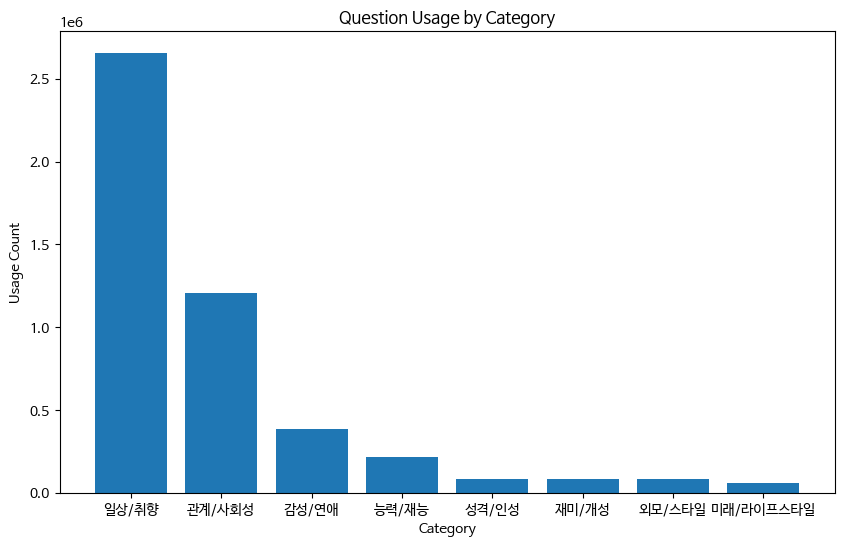

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    category_usage['category'],
    category_usage['usage_count']
)

plt.xlabel('Category')
plt.ylabel('Usage Count')

plt.title('Question Usage by Category')

plt.show()

## 질문 카테고리 분석

질문 카테고리 분석 결과,
일상·취향 기반 질문 소비가 가장 높은 비중을 차지하는 것으로 나타났다.

특히:

- 음식
- 여행
- 게임
- 놀이기구
- 생활 습관

등 가벼운 생활형 질문 소비가 활발하게 나타났다.

반면 외모·인기 중심 질문보다
친구의 일상적 캐릭터를 해석하는 질문 소비가 상대적으로 더 많이 나타났다.

다만 질문 표현의 다양성이 매우 높아,
일부 질문은 명확한 단일 카테고리로 분류하기 어려운 한계가 존재했다.

## 질문 카테고리 분류 기준 및 키워드

| 카테고리 | 분류 기준 | 사용 키워드 |
|---|---|---|
| 관계/사회성 | 친구 관계 및 함께하는 상황 중심 질문 | 친구, 같이, 연락, 잘 지낼, 친해, 약속 |
| 성격/인성 | 성격, 태도, 배려, 인성 관련 질문 | 착한, 다정, 센스, 인사성, 성실, 깔끔, 배려, 예의, 시원시원 |
| 능력/재능 | 특정 능력, 실력, 수행 관련 질문 | 공부, 발표, 게임, 운동, 춤, 노래, 가르쳐, 기억, 잘할 |
| 감성/연애 | 감정, 연애, 이상형 관련 질문 | 연인, 결혼, 사랑, 이상형, 울, 눈물 |
| 외모/스타일 | 외모, 분위기, 패션 관련 질문 | 옷, 패션, 어울리는, 잘생, 예쁜, 스타일 |
| 재미/개성 | 웃김, 특이함, 개성 관련 질문 | 특이, 웃긴, 개성, 틱톡, 릴스, 재밌 |
| 미래/라이프스타일 | 미래 모습, 성공, 직업 관련 질문 | 돈, 성공, 미래, 학생회장, 직업, 유명 |
| 일상/취향 | 음식, 취미, 생활 습관 관련 질문 | 라면, 먹방, 놀이기구, 여행, 드라마, 책, 음식, 캠핑 |

In [72]:
# STEP 9. 카테고리별 소비량 분석

# 목적 : 유저들이 어떤 질문 유형을 가장 많이 소비하는가?

In [73]:
category_usage['ratio'] = (
    category_usage['usage_count']
    / category_usage['usage_count'].sum()
) * 100

category_usage

,category,usage_count,ratio
6,일상/취향,2657914,55.726035
1,관계/사회성,1203923,25.241545
0,감성/연애,386232,8.097771
2,능력/재능,216700,4.543349
4,성격/인성,83364,1.747816
7,재미/개성,80426,1.686218
5,외모/스타일,80031,1.677936
3,미래/라이프스타일,61019,1.279329


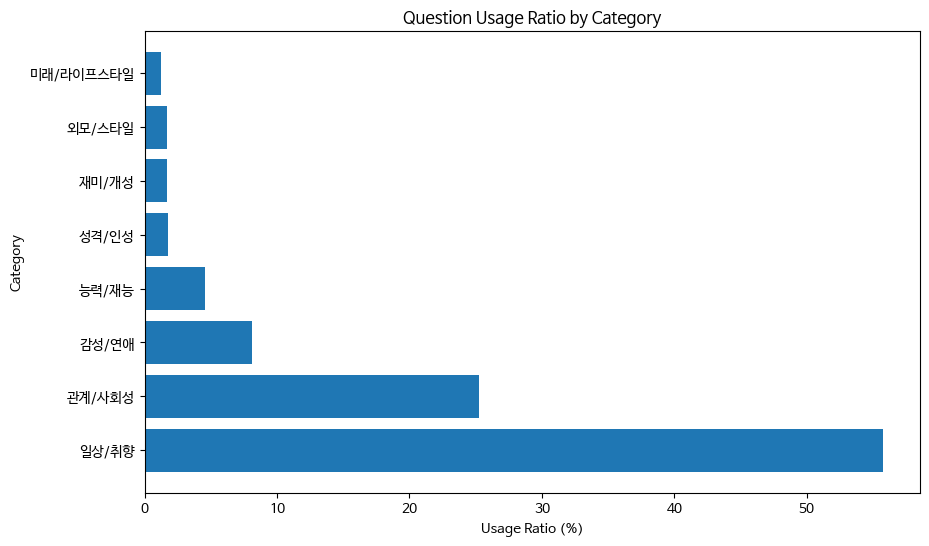

In [74]:
plt.figure(figsize=(10,6))

plt.barh(
    category_usage['category'],
    category_usage['ratio']
)

plt.xlabel('Usage Ratio (%)')
plt.ylabel('Category')

plt.title('Question Usage Ratio by Category')

plt.show()

In [76]:
# STEP 10. 카테고리별 반복 소비 분석

# 목적 : 특정 질문 유형에 소비가 반복 집중되는가?

In [78]:
# full_data에도 category 붙이기

full_data = full_data.merge(
    question_usage[['question_text', 'category']],
    on='question_text',
    how='left'
)

full_data.head()

,id,created_at,question_piece_id,user_id,id_x,is_voted,created_at_x,question_id,is_skipped,id_y,question_text,created_at_y,category
0,3088872,2023-04-28 12:27:49,998458,849444,998458,1,2023-04-28 12:27:22,252,0,252,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-01 11:09:27,일상/취향
1,3088873,2023-04-28 12:27:49,998458,849454,998458,1,2023-04-28 12:27:22,252,0,252,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-01 11:09:27,일상/취향
2,3088874,2023-04-28 12:27:49,998458,849460,998458,1,2023-04-28 12:27:22,252,0,252,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-01 11:09:27,일상/취향
3,3088875,2023-04-28 12:27:49,998458,849469,998458,1,2023-04-28 12:27:22,252,0,252,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-01 11:09:27,일상/취향
4,3088964,2023-04-28 12:28:02,998459,849446,998459,1,2023-04-28 12:27:22,244,0,244,대학교에서 학생회장할 것 같은 사람은?,2023-04-01 11:09:26,미래/라이프스타일


In [79]:
category_diversity = (
    full_data
    .groupby('category')['question_text']
    .nunique()
    .reset_index(name='unique_questions')
)

category_diversity

,category,unique_questions
0,감성/연애,251
1,관계/사회성,1190
2,능력/재능,154
3,미래/라이프스타일,47
4,성격/인성,25
5,외모/스타일,53
6,일상/취향,2159
7,재미/개성,23


In [80]:
# 카테고리별 평균 사용량 분석

category_avg_usage = (
    question_usage
    .groupby('category')['usage_count']
    .mean()
    .reset_index(name='avg_usage')
    .sort_values('avg_usage', ascending=False)
)

category_avg_usage

,category,avg_usage
7,재미/개성,3496.782609
4,성격/인성,3334.560000
0,감성/연애,1538.772908
5,외모/스타일,1510.018868
2,능력/재능,1407.142857
3,미래/라이프스타일,1298.276596
6,일상/취향,1231.085688
1,관계/사회성,1011.700000


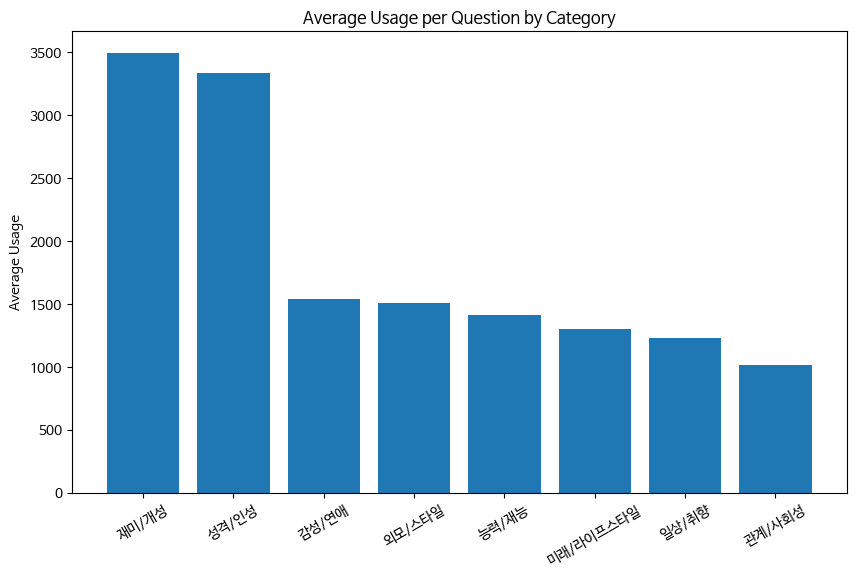

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    category_avg_usage['category'],
    category_avg_usage['avg_usage']
)

plt.xticks(rotation=30)

plt.ylabel('Average Usage')
plt.title('Average Usage per Question by Category')

plt.show()

## 카테고리별 반복 소비 분석

카테고리별 평균 사용량 분석 결과,
질문 수가 적은 카테고리일수록
평균 소비량이 높게 나타나는 경향이 확인되었다.

특히 재미/개성형과 성격/인성형 질문은
질문 종류 수는 적지만 평균 사용량은 매우 높게 나타났다.

이는 일부 대표 질문이 반복적으로 소비되는 구조일 가능성을 시사한다.

반면 일상/취향형과 관계/사회성 질문은
질문 종류 수 자체가 매우 많았으며,
다양한 질문이 비교적 고르게 소비되는 패턴이 나타났다.

즉 서비스는 단순 인기 질문 반복 구조라기보다,
다양한 생활형 질문 풀을 기반으로 소비가 이루어지는 특성을 보였다.

In [82]:
# STEP 11. TOP 질문 편중 분석
# 목적 : 소수 질문이 전체 소비를 과도하게 차지하는가?

In [83]:
# 누적 비율 계산

pareto_df = question_usage.sort_values(
    'usage_count',
    ascending=False
).reset_index(drop=True)

pareto_df['cum_usage'] = (
    pareto_df['usage_count']
    .cumsum()
)

pareto_df['cum_ratio'] = (
    pareto_df['cum_usage']
    / pareto_df['usage_count'].sum()
)

In [84]:
top_50_ratio_idx = (
    pareto_df[pareto_df['cum_ratio'] >= 0.5]
    .index[0]
)

top_80_ratio_idx = (
    pareto_df[pareto_df['cum_ratio'] >= 0.8]
    .index[0]
)

print("50% 소비 차지 질문 수:", top_50_ratio_idx + 1)
print("80% 소비 차지 질문 수:", top_80_ratio_idx + 1)

50% 소비 차지 질문 수: 358
80% 소비 차지 질문 수: 940


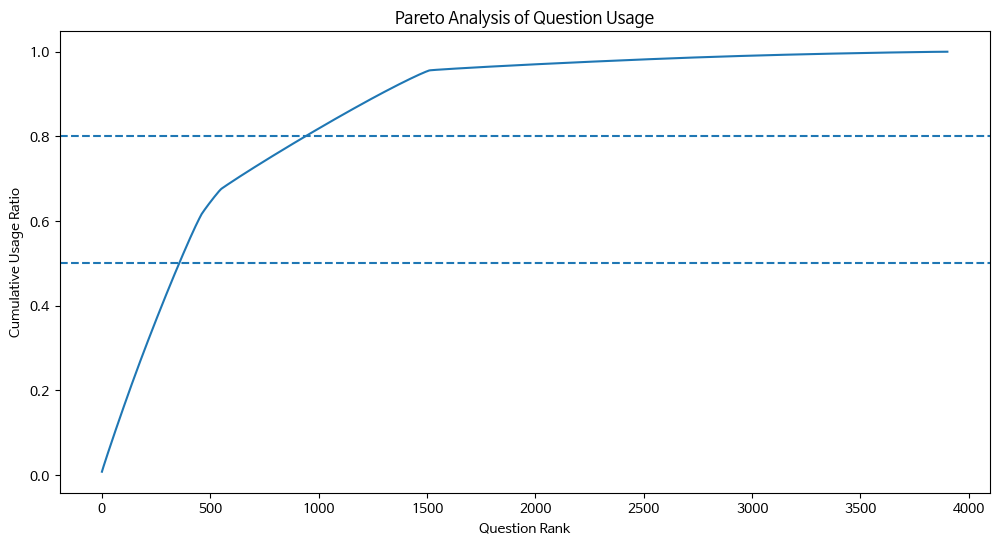

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    range(len(pareto_df)),
    pareto_df['cum_ratio']
)

plt.axhline(
    y=0.5,
    linestyle='--'
)

plt.axhline(
    y=0.8,
    linestyle='--'
)

plt.xlabel('Question Rank')
plt.ylabel('Cumulative Usage Ratio')

plt.title('Pareto Analysis of Question Usage')

plt.show()

## 질문 소비 편중(Pareto) 분석

질문 사용량 기준 Pareto 분석 결과,
전체 소비의 50%가 상위 358개 질문에서 발생한 것으로 나타났다.

또한 전체 소비의 80%는 상위 940개 질문에서 발생하였다.

이는 일부 인기 질문 중심의 소비 집중 현상이 존재함을 의미한다.

다만 전체 질문 수 대비 상위 질문 비중이 극단적으로 높지는 않았으며,
다양한 질문들이 함께 소비되는 롱테일(Long Tail) 구조 또한 확인되었다.

즉 서비스는:

- 일부 인기 질문이 소비를 주도하면서도
- 동시에 다양한 질문 풀이 함께 유지되는 구조

를 가지고 있었던 것으로 해석할 수 있다.

In [86]:
# STEP 12. TOP 실제 질문 분석

In [89]:
question_usage = question_usage[
    question_usage['question_text'] != 'vote'
]

In [90]:
# 가장 많이 소비된 질문 TOP 20

top20_questions = (
    question_usage
    .sort_values('usage_count', ascending=False)
    .head(20)
)

top20_questions[
    ['question_text', 'usage_count', 'category']
]

,question_text,usage_count,category
23,2세가 가장 귀여울 것 같은 사람은?,8510,감성/연애
500,같이 캠핑가고 싶은 사람은?,8307,관계/사회성
1255,라면 잘 끓일 것 같은 사람은?,8272,일상/취향
3269,처음 보는 사람과 가장 빨리 친해질 것 같은 사람은?,7804,관계/사회성
3357,축제에서 공연을 제일 잘 할거 같은 사람은?,7773,일상/취향
1463,모든 사람과 잘 지낼 것 같은 사람은?,7759,관계/사회성
2296,앞으로의 인생을 가장 재미있게 살것 같은 사람은?,7726,일상/취향
1611,반려동물과 가장 잘 지낼거 같은 사람은?,7673,관계/사회성
129,가장 깔끔할 것 같은 친구는?,7662,관계/사회성
2453,여기서 제일 특이한 친구는?,7614,관계/사회성


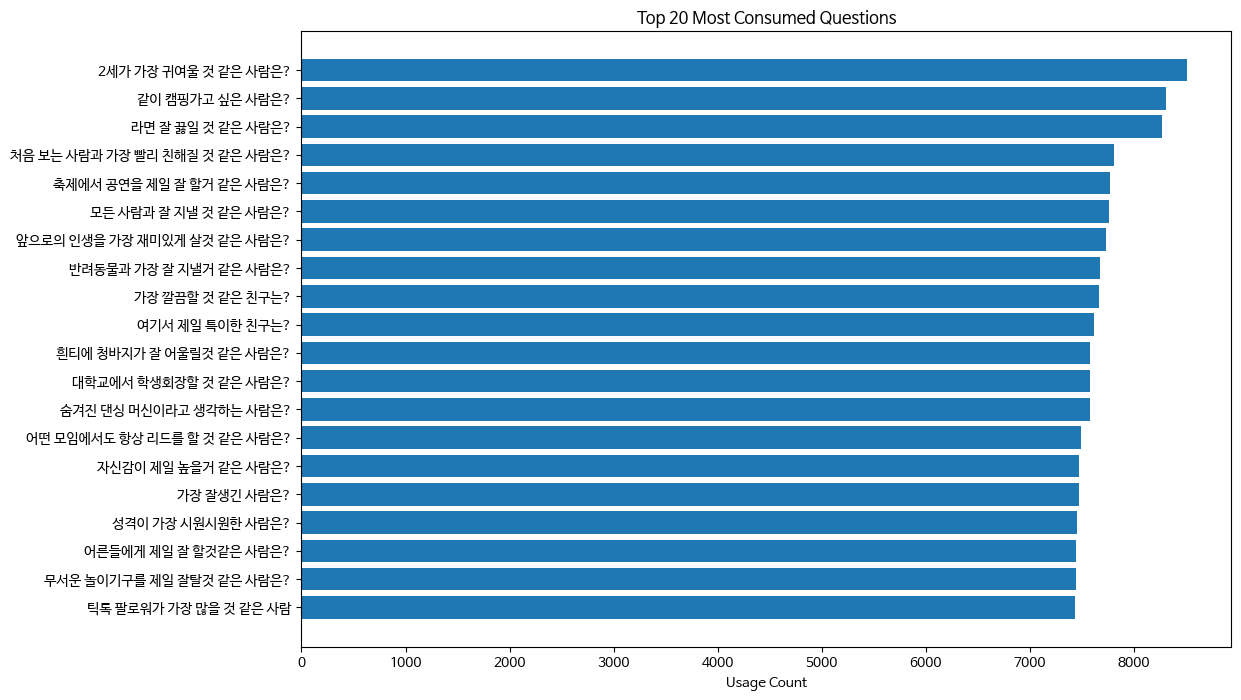

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.barh(
    top20_questions['question_text'][::-1],
    top20_questions['usage_count'][::-1]
)

plt.xlabel('Usage Count')
plt.title('Top 20 Most Consumed Questions')

plt.show()

## 상위 소비 질문 분석

상위 소비 질문 분석 결과,
단순 외모·인기 평가형 질문보다
친구의 성격, 관계성, 생활 캐릭터를 평가하는 질문이 다수 소비된 것으로 나타났다.

특히 상위 질문에는:

- 같이 게임 가고 싶은 사람
- 라면 잘 끓일 것 같은 사람
- 처음 보는 사람과 가장 빨리 친해질 것 같은 사람
- 축제에서 공연을 제일 잘할 것 같은 사람

등 실제 생활 상황을 기반으로 한 질문들이 다수 포함되어 있었다.

또한:

- 가장 깔끔할 것 같은 친구
- 성격이 가장 시원시원한 사람
- 어른들에게 제일 잘할 것 같은 사람

과 같이 성격·인성 기반 질문 소비 역시 활발하게 나타났다.

반면 단순 인기·외모 중심 질문 비중은 상대적으로 낮게 나타났으며,
전반적으로 긍정적·호감형 표현 중심의 질문 소비 패턴이 확인되었다.

이는 서비스가 단순 인기투표 플랫폼이라기보다,
친구의 이미지와 캐릭터를 가볍게 해석하고 공유하는
관계 기반 상호작용 플랫폼 형태로 사용되었을 가능성을 시사한다.

In [93]:
# STEP 13. 유저 행동 분석
# 핵심 질문: "사람들은 얼마나 많이 참여했는가?"

In [94]:
# 유저별 참여 횟수 분포

In [95]:
user_activity = (
    full_data
    .groupby('user_id')
    .size()
    .reset_index(name='participation_count')
)

user_activity.head()

,user_id,participation_count
0,833112,5
1,833113,69
2,833154,19
3,833202,2
4,833203,256


In [96]:
user_activity['participation_count'].describe()

,participation_count
count,19994.000000
mean,238.552016
std,447.335059
min,1.000000
25%,7.000000
50%,29.000000
75%,220.000000
max,4226.000000


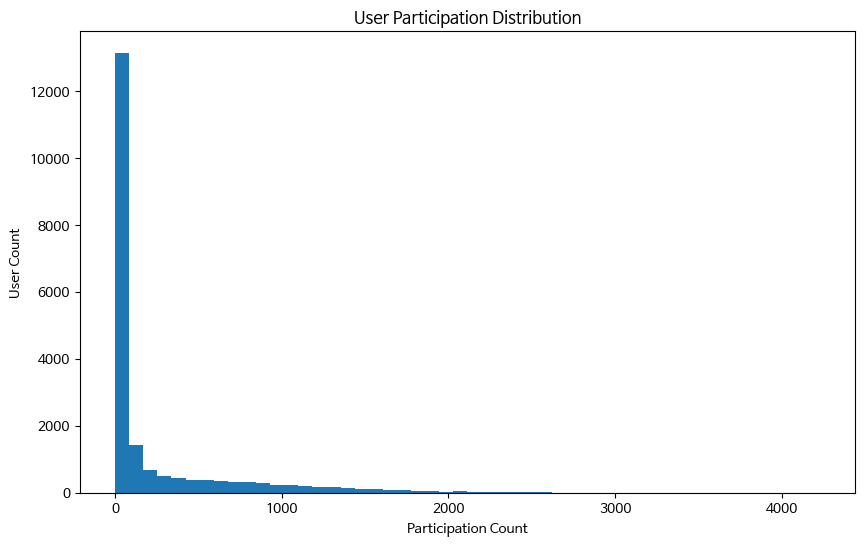

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    user_activity['participation_count'],
    bins=50
)

plt.xlabel('Participation Count')
plt.ylabel('User Count')

plt.title('User Participation Distribution')

plt.show()

## 유저 참여 분포 분석

유저별 질문 참여 횟수 분석 결과,
대부분의 유저는 비교적 적은 횟수만 참여하는 반면,
일부 유저는 매우 높은 참여 횟수를 기록하는 Long Tail 구조가 확인되었다.

특히:

- 중앙값(Median): 29회
- 평균(Mean): 238회
- 최대 참여 횟수: 4,226회

로 나타났으며,
평균과 중앙값의 차이가 매우 크게 나타났다.

이는 소수의 헤비유저가 전체 참여량을 크게 끌어올리는 구조가 존재함을 의미한다.

즉 서비스는:

- 다수의 라이트 유저와
- 소수의 고활동 유저

가 함께 공존하는 참여 구조를 가지고 있었던 것으로 해석된다.

In [99]:
# STEP 14. TOP 10% 유저 기여도 분석
# 목적 : 소수 헤비유저가 전체 활동을 얼마나 차지하는가?

In [101]:
# 1. 참여량 기준 정렬
user_activity_sorted = user_activity.sort_values(
    'participation_count',
    ascending=False
).reset_index(drop=True)

user_activity_sorted.head()

,user_id,participation_count
0,860304,4226
1,940572,4070
2,1137034,3948
3,1207066,3920
4,994573,3674


In [102]:
# 2. 상위 10% 유저 추출

top_10_percent = int(len(user_activity_sorted) * 0.1)

top_users = user_activity_sorted.head(top_10_percent)

top_users.head()

,user_id,participation_count
0,860304,4226
1,940572,4070
2,1137034,3948
3,1207066,3920
4,994573,3674


In [103]:
# 3. 전체 참여량 대비 비율 계산

top_user_ratio = (
    top_users['participation_count'].sum()
    / user_activity_sorted['participation_count'].sum()
) * 100

print(f"상위 10% 유저 참여 비율: {top_user_ratio:.2f}%")

상위 10% 유저 참여 비율: 57.41%


In [104]:
# 4. 상위 1%

top_1_percent = int(len(user_activity_sorted) * 0.01)

top1_users = user_activity_sorted.head(top_1_percent)

top1_ratio = (
    top1_users['participation_count'].sum()
    / user_activity_sorted['participation_count'].sum()
) * 100

print(f"상위 1% 유저 참여 비율: {top1_ratio:.2f}%")

상위 1% 유저 참여 비율: 10.27%


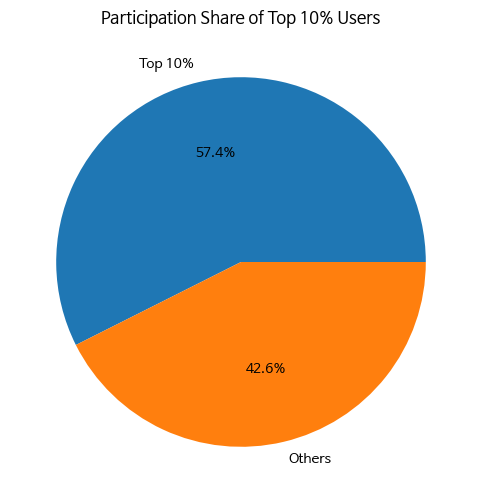

In [105]:
labels = ['Top 10%', 'Others']
sizes = [
    top_user_ratio,
    100 - top_user_ratio
]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title('Participation Share of Top 10% Users')

plt.show()

## 상위 유저 참여 편중 분석

유저 참여 기여도 분석 결과,
상위 10% 유저가 전체 참여의 57.4%를 차지하는 것으로 나타났다.

이는 소수의 고활동 유저가
서비스 내 질문 소비와 참여를 크게 주도하고 있었음을 의미한다.

앞선 유저 참여 분포 분석에서도:

- 중앙값(Median): 29회
- 최대 참여 횟수: 4,226회

로 나타나,
일부 헤비유저 중심의 참여 구조가 확인되었다.

즉 서비스는:

- 다수의 라이트 유저와
- 반복적으로 활동하는 코어 유저

가 함께 공존하는 구조를 가지고 있었으며,
특히 코어 유저의 활동성이 전체 서비스 활성도 유지에 중요한 역할을 했을 가능성이 존재한다.

In [106]:
# STEP 15. 헤비유저 질문 소비 분석

In [107]:
heavy_user_ids = top_users['user_id'].unique()

len(heavy_user_ids)

1999

In [108]:
heavy_data = full_data[
    full_data['user_id'].isin(heavy_user_ids)
]

light_data = full_data[
    ~full_data['user_id'].isin(heavy_user_ids)
]

In [109]:
heavy_category = (
    heavy_data
    .groupby('category')
    .size()
    .reset_index(name='count')
)

heavy_category['ratio'] = (
    heavy_category['count']
    / heavy_category['count'].sum()
) * 100

heavy_category

,category,count,ratio
0,감성/연애,220695,8.059677
1,관계/사회성,694051,25.346415
2,능력/재능,123553,4.512097
3,미래/라이프스타일,34457,1.258353
4,성격/인성,46795,1.708931
5,외모/스타일,45503,1.661748
6,일상/취향,1528189,55.808741
7,재미/개성,45018,1.644036


In [110]:
light_category = (
    light_data
    .groupby('category')
    .size()
    .reset_index(name='count')
)

light_category['ratio'] = (
    light_category['count']
    / light_category['count'].sum()
) * 100

light_category

,category,count,ratio
0,감성/연애,165537,8.149121
1,관계/사회성,509872,25.100180
2,능력/재능,93147,4.585477
3,미래/라이프스타일,26562,1.307605
4,성격/인성,36569,1.800233
5,외모/스타일,34528,1.699758
6,일상/취향,1129725,55.614548
7,재미/개성,35408,1.743079


In [111]:
compare_df = heavy_category.merge(
    light_category,
    on='category',
    suffixes=('_heavy', '_light')
)

compare_df

,category,count_heavy,ratio_heavy,count_light,ratio_light
0,감성/연애,220695,8.059677,165537,8.149121
1,관계/사회성,694051,25.346415,509872,25.100180
2,능력/재능,123553,4.512097,93147,4.585477
3,미래/라이프스타일,34457,1.258353,26562,1.307605
4,성격/인성,46795,1.708931,36569,1.800233
5,외모/스타일,45503,1.661748,34528,1.699758
6,일상/취향,1528189,55.808741,1129725,55.614548
7,재미/개성,45018,1.644036,35408,1.743079


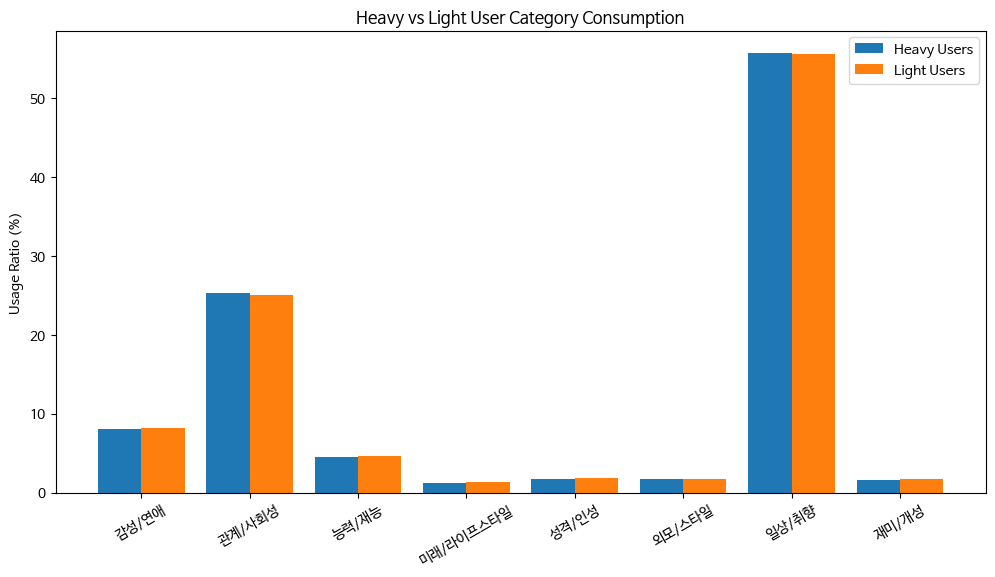

In [112]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(compare_df))

plt.figure(figsize=(12,6))

plt.bar(
    x - 0.2,
    compare_df['ratio_heavy'],
    width=0.4,
    label='Heavy Users'
)

plt.bar(
    x + 0.2,
    compare_df['ratio_light'],
    width=0.4,
    label='Light Users'
)

plt.xticks(x, compare_df['category'], rotation=30)

plt.ylabel('Usage Ratio (%)')

plt.title('Heavy vs Light User Category Consumption')

plt.legend()

plt.show()

## 헤비유저 vs 일반유저 소비 패턴 비교

헤비유저와 일반유저의 질문 카테고리 소비 비율을 비교한 결과,
두 집단 간 소비 패턴 차이는 크지 않은 것으로 나타났다.

특히:

- 일상/취향형
- 관계/사회성형

질문 소비 비중이 양 집단 모두에서 높게 나타났으며,
전반적인 카테고리 분포 역시 유사한 형태를 보였다.

이는 헤비유저가 특정 카테고리에만 집중적으로 몰입했다기보다,
전체 서비스의 질문 소비 구조 자체를 반복적으로 이용했을 가능성을 시사한다.

즉 서비스는 특정 niche 콘텐츠 중심 구조라기보다,
전체적인 질문 소비 경험 자체가 반복 참여를 유도하는 형태였을 가능성이 존재한다.

In [113]:
# STEP 16. 시간 흐름 분석

In [117]:
# 일별 참여량 분석
full_data['created_at'] = pd.to_datetime(
    full_data['created_at']
)

full_data['date'] = (
    full_data['created_at']
    .dt.date
)

In [115]:
daily_activity = (
    full_data
    .groupby('date')
    .size()
    .reset_index(name='participation_count')
)

daily_activity.head()

,date,participation_count
0,2023-04-28,12181
1,2023-04-29,44262
2,2023-04-30,63185
3,2023-05-01,47863
4,2023-05-02,53386


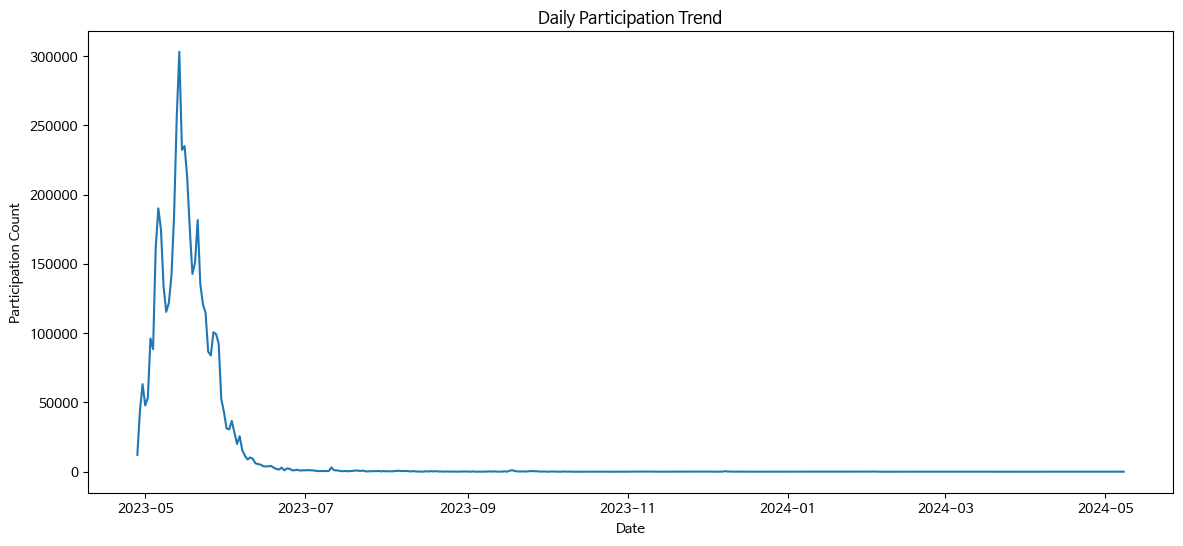

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    daily_activity['date'],
    daily_activity['participation_count']
)

plt.xlabel('Date')
plt.ylabel('Participation Count')

plt.title('Daily Participation Trend')

plt.show()

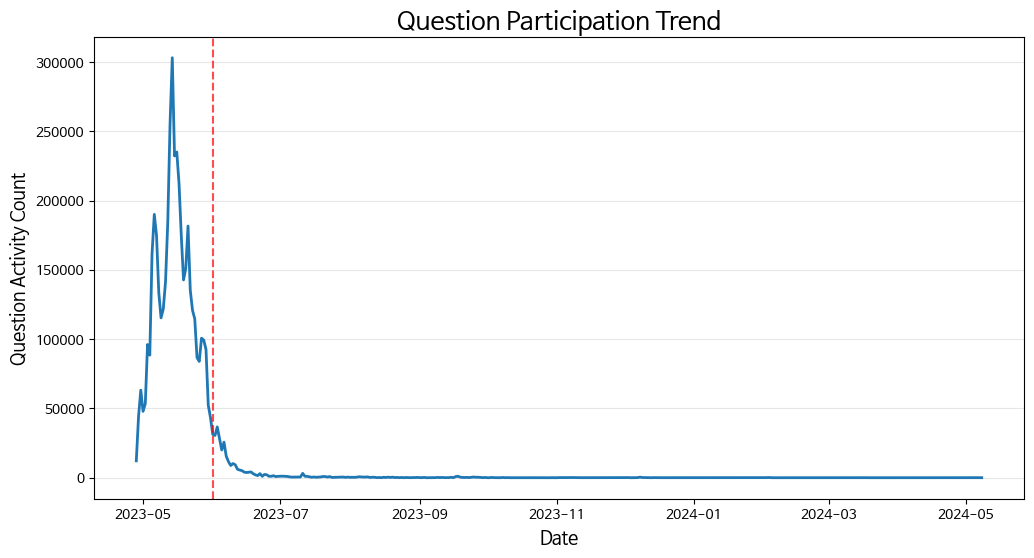

In [144]:
# 날짜 컬럼 생성
full_data['date'] = pd.to_datetime(full_data['created_at']).dt.date

# 일별 참여량 집계
daily_trend = (
    full_data
    .groupby('date')
    .size()
)

# index datetime 변환
daily_trend.index = pd.to_datetime(daily_trend.index)

# 그래프
plt.figure(figsize=(12,6))

plt.plot(
    daily_trend.index,
    daily_trend.values,
    linewidth=2
)

# 감소 시점 표시
plt.axvline(
    x=pd.to_datetime('2023-06-01'),
    color='red',
    linestyle='--',
    alpha=0.7
)

plt.title('Question Participation Trend', fontsize=18)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Question Activity Count', fontsize=13)

plt.grid(axis='y', alpha=0.3)

plt.show()

In [120]:
# 카테고리별 시간 흐름

category_daily = (
    full_data
    .groupby(['date', 'category'])
    .size()
    .reset_index(name='count')
)

category_daily.head()

,date,category,count
0,2023-04-28,감성/연애,1012
1,2023-04-28,관계/사회성,2288
2,2023-04-28,능력/재능,831
3,2023-04-28,미래/라이프스타일,348
4,2023-04-28,성격/인성,497


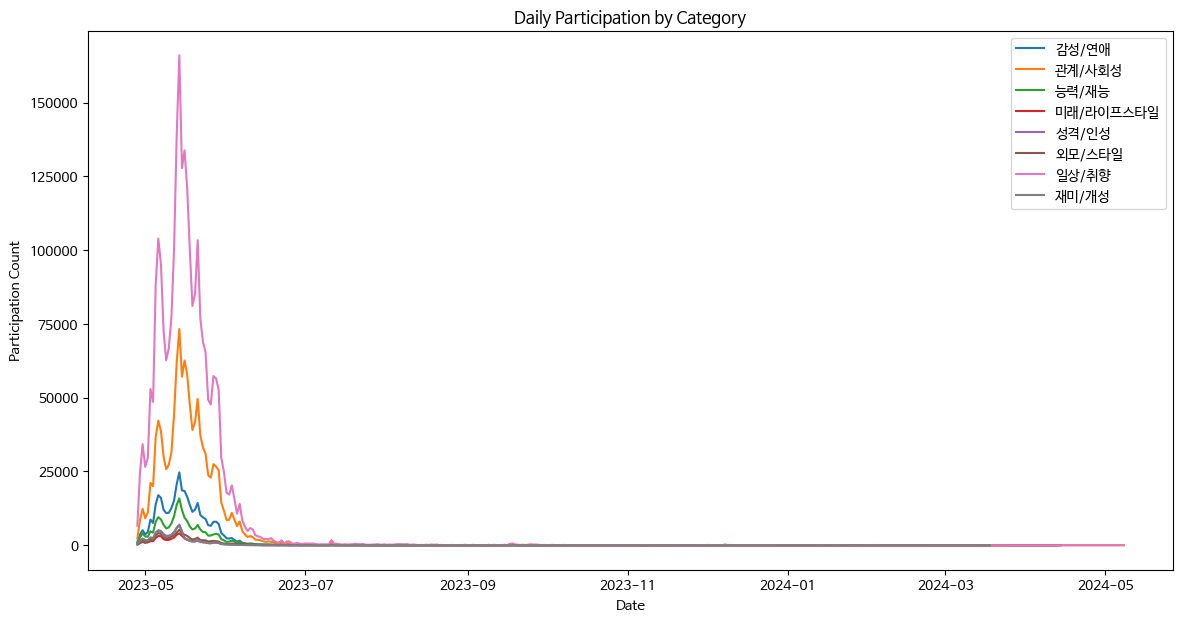

In [119]:
plt.figure(figsize=(14,7))

for cat in category_daily['category'].unique():

    temp = category_daily[
        category_daily['category'] == cat
    ]

    plt.plot(
        temp['date'],
        temp['count'],
        label=cat
    )

plt.legend()

plt.xlabel('Date')
plt.ylabel('Participation Count')

plt.title('Daily Participation by Category')

plt.show()

## 시간 흐름 기반 서비스 활동 분석

일별 참여량 분석 결과,
서비스는 단기간 폭발적으로 성장한 이후
급격하게 활동량이 감소하는 패턴을 보였다.

특히 2023년 5월 전후 참여량이 최고치를 기록한 이후,
전체 활동량이 빠르게 감소하는 흐름이 확인되었다.

이는 서비스가:

- 관계 기반 바이럴 확산
- 신규성 중심 소비
- 짧은 유행 사이클

특성을 가졌을 가능성을 시사한다.

또한 카테고리별 참여 흐름 분석 결과,
모든 질문 유형이 유사한 감소 패턴을 보였다.

즉 특정 카테고리 문제라기보다,
서비스 전체 질문 소비 경험 자체에서
활동 피로 또는 관심 감소가 발생했을 가능성이 존재한다.

한편 감소 이후에도
일상/취향형 질문 소비 비중은 지속적으로 가장 높게 유지되었으며,
서비스의 핵심 콘텐츠 구조가 생활형 관계 질문 중심이었다는 점 역시 확인되었다.

In [122]:
# 추가 분석 - 질문 다양성 감소
# 시간이 지나며 소비 질문 종류가 줄어들었는가?

In [123]:
daily_unique_questions = (
    full_data
    .groupby('date')['question_text']
    .nunique()
    .reset_index(name='unique_question_count')
)

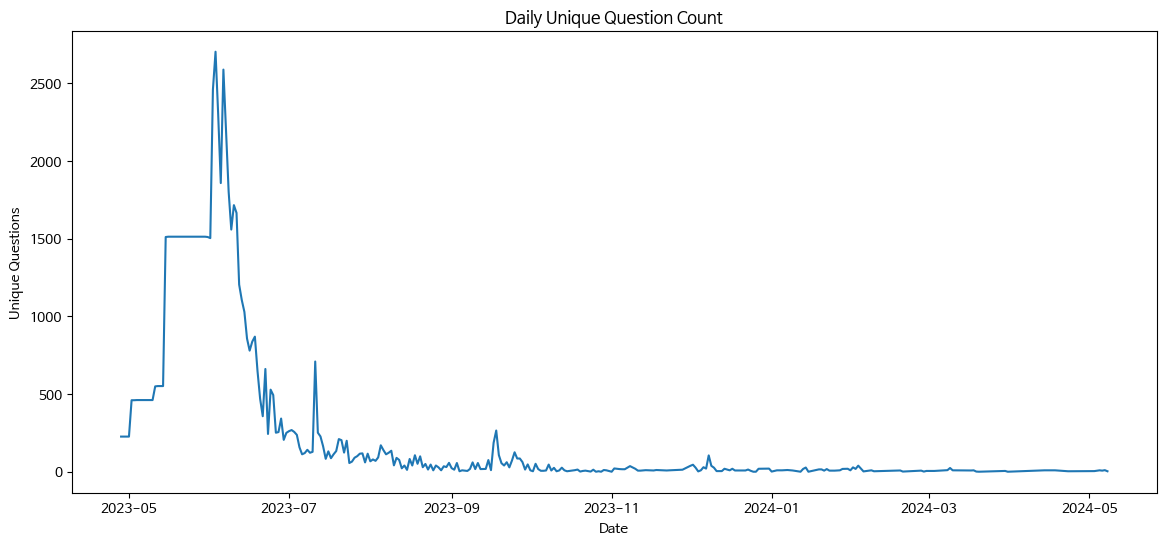

In [124]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_unique_questions['date'],
    daily_unique_questions['unique_question_count']
)

plt.title('Daily Unique Question Count')

plt.xlabel('Date')
plt.ylabel('Unique Questions')

plt.show()

### 질문 다양성 감소 현상 확인

일별 고유 질문 수(unique question count)를 분석한 결과,
서비스 초기에는 다양한 질문이 활발하게 소비되었으나,
시간이 지날수록 소비되는 질문 종류가 빠르게 감소하는 패턴이 나타났다.

이는 단순 사용자 감소를 넘어,
서비스 내 콘텐츠 다양성 자체가 축소되었음을 의미한다.

특히 일부 인기 질문 중심 소비 구조가 강화되며,
질문 반복 노출 및 콘텐츠 피로 가능성이 함께 확인되었다.

In [125]:
# 추가 분석 - “재사용 질문 집중도” 분석

In [126]:
question_usage['usage_count'].describe()

,usage_count
count,3901.000000
mean,1212.910279
std,2000.525306
min,4.000000
25%,75.000000
50%,123.000000
75%,1427.000000
max,8510.000000


In [127]:
top100_ratio = (
    question_usage
    .sort_values('usage_count', ascending=False)
    .head(100)['usage_count']
    .sum()
    /
    question_usage['usage_count'].sum()
) * 100

print(top100_ratio)

15.366254237764561


In [129]:
# 추가 분석 : “초기 vs 후기 질문 차이”

In [132]:
full_data['period'] = np.where(
    full_data['date'] < pd.to_datetime('2023-07-01').date(),
    '초기',
    '후기'
)

In [133]:
period_top_questions = (
    full_data
    .groupby(['period', 'question_text'])
    .size()
    .reset_index(name='usage_count')
)

In [134]:
period_top_questions

,period,question_text,usage_count
0,초기,1000만원 주고 365일 학교 오라고 하면 올 것 같은 사람은?,43
1,초기,10년 뒤에 가장 돈을 많이 벌었을 것 같은 사람은?,7328
2,초기,10년 뒤에도 자주 만날 것 같은 사람은?,1257
3,초기,10년 안에 연예인이 될 것 같은 사람은?,5627
4,초기,10년 후 1명에게만 연락할 수 있다면 누구한테 하고 싶어?,6584
...,...,...,...
7519,후기,힘을 숨기고 있을 것 같은 사람은?,20
7520,후기,힙한 매력을 가진 사람은?,16
7521,후기,힙합 남친을 두면 가장 잘 어울릴 것 같은 사람은?,24
7522,후기,힙합 좋아할 것 같은 사람,8


In [138]:
period_top_questions = period_top_questions[
    period_top_questions['question_text'] != 'vote'
]

In [139]:
early_top = (
    period_top_questions[
        period_top_questions['period'] == '초기'
    ]
    .sort_values('usage_count', ascending=False)
    .head(10)
)

early_top

,period,question_text,usage_count
23,초기,2세가 가장 귀여울 것 같은 사람은?,8490
500,초기,같이 캠핑가고 싶은 사람은?,8287
1254,초기,라면 잘 끓일 것 같은 사람은?,8260
3268,초기,처음 보는 사람과 가장 빨리 친해질 것 같은 사람은?,7792
3356,초기,축제에서 공연을 제일 잘 할거 같은 사람은?,7769
1462,초기,모든 사람과 잘 지낼 것 같은 사람은?,7743
2295,초기,앞으로의 인생을 가장 재미있게 살것 같은 사람은?,7706
1610,초기,반려동물과 가장 잘 지낼거 같은 사람은?,7673
129,초기,가장 깔끔할 것 같은 친구는?,7638
2452,초기,여기서 제일 특이한 친구는?,7602


In [140]:
late_top = (
    period_top_questions[
        period_top_questions['period'] == '후기'
    ]
    .sort_values('usage_count', ascending=False)
    .head(10)
)

late_top

,period,question_text,usage_count
6362,후기,웃긴 영상보면 가장 먼저 공유해주고 싶은 사람,48
4540,후기,기말고사를 제일 열심히 준비할 것 같은 친구,47
6646,후기,잡기술이 가장 많은 사람은?,40
4154,후기,가장 자만추인것 같은 사람,40
5685,후기,새벽에 같이 편의점 가고 싶은 사람,39
4774,후기,내 핸드폰을 맡길 수 있는 사람은?,36
4856,후기,노래방에서 같이 춤 출 수 있는 친구는?,36
6228,후기,연예인의 기질이 보이는 친구,36
5028,후기,드라마 결말을 잘 맞출것 같은 사람은?,36
5106,후기,마스크 벗은 모습이 궁금한 사람은?,36


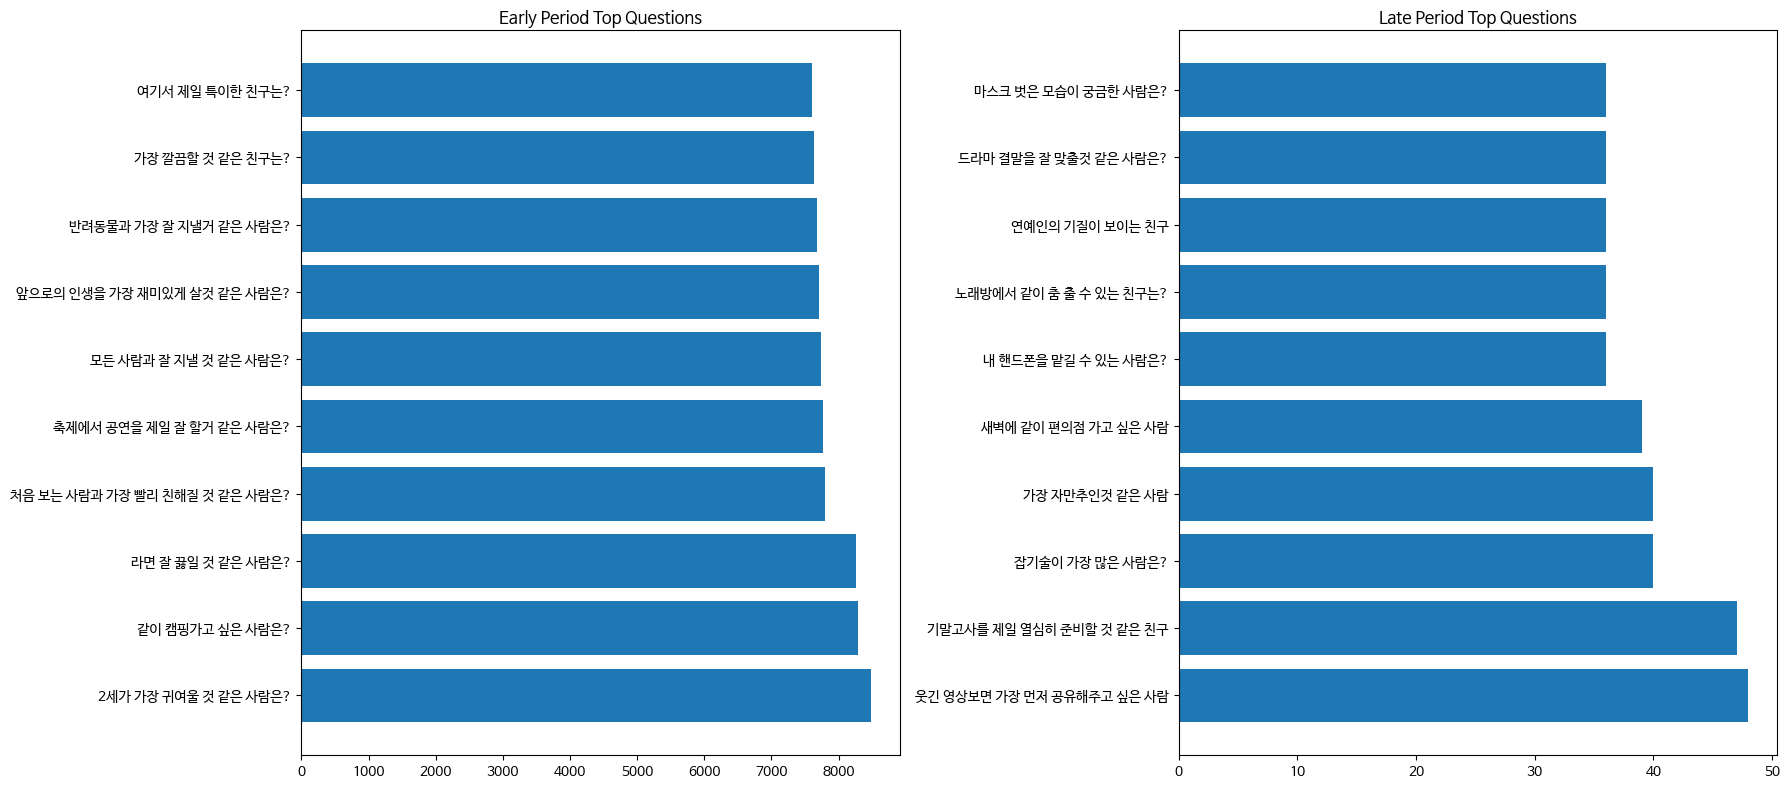

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(18,8))

# 초기
axes[0].barh(
    early_top['question_text'],
    early_top['usage_count']
)

axes[0].set_title('Early Period Top Questions')

# 후기
axes[1].barh(
    late_top['question_text'],
    late_top['usage_count']
)

axes[1].set_title('Late Period Top Questions')

plt.tight_layout()

plt.show()

초기:
폭넓은 관계형 질문 기반 바이럴 확산

↓

중기:
반복 소비 구조 강화
헤비유저 중심 참여 증가

↓

후기:
질문 다양성 감소
소규모 관계 중심 소비로 축소
전체 활동 급감

# 최종 인사이트

## 1. 서비스는 관계 기반 놀이형 질문 플랫폼으로 소비되었다

질문 소비 패턴 분석 결과,
사용자들은 단순 인기 투표보다
친구 관계와 일상 행동을 기반으로 한 질문에 높은 반응을 보였다.

특히:

- 같이 캠핑가고 싶은 사람
- 반려동물과 가장 잘 지낼 것 같은 사람
- 앞으로의 인생을 가장 재미있게 살 것 같은 사람

등 관계형·생활형 질문이 높은 소비량을 기록하였다.

이는 서비스가 단순 투표 플랫폼보다
친구 관계 기반의 가벼운 놀이형 커뮤니케이션 서비스로 기능했음을 의미한다.

---

## 2. 질문 소비는 일부 인기 질문 중심으로 집중되는 구조였다

질문 소비 Pareto 분석 결과,
상위 일부 질문이 전체 소비를 크게 차지하는 구조가 확인되었다.

특히:

- 상위 358개 질문이 전체 소비의 50%
- 상위 940개 질문이 전체 소비의 80%

를 차지하였다.

또한 상위 100개 질문이 전체 소비의 약 15.3%를 차지하는 것으로 나타났다.

이는 서비스가 시간이 지날수록
일부 인기 질문 중심의 반복 소비 구조로 고착되었음을 시사한다.

---

## 3. 서비스 활동은 일부 헤비유저 중심 구조를 보였다

유저 참여 분포 분석 결과,
상위 10% 유저가 전체 참여의 57.4%를 차지하는 것으로 나타났다.

또한 평균 참여 횟수는 238회였지만,
중앙값은 29회에 불과하여
소수의 헤비유저가 전체 활동량을 크게 끌어올리는 구조가 존재하였다.

이는 서비스가 일부 코어 유저 중심으로 유지되는 구조였음을 의미한다.

---

## 4. 헤비유저와 일반유저의 소비 패턴 차이는 크지 않았다

헤비유저와 일반유저의 질문 카테고리 소비 패턴을 비교한 결과,
두 집단 간 소비 구조 차이는 크지 않은 것으로 나타났다.

즉 헤비유저는 특정 niche 콘텐츠보다,
서비스 전체 질문 소비 구조 자체를 반복적으로 소비하는 경향을 보였다.

이는 서비스 UX 자체가 반복 참여를 유도했을 가능성을 시사한다.

---

## 5. 서비스는 짧고 강한 바이럴형 성장 구조를 보였다

일별 참여량 분석 결과,
서비스는 단기간 폭발적으로 성장한 이후 빠르게 활동량이 감소하는 패턴을 보였다.

특히 2023년 5월 전후 참여량이 최고치를 기록한 이후,
전체 활동량이 급격히 감소하였다.

또한 카테고리별 흐름 역시 유사한 감소 패턴을 보였다.

이는 특정 질문 유형 문제가 아니라,
서비스 전체 질문 소비 경험 자체에서 피로가 발생했을 가능성을 시사한다.

---

## 6. 시간 흐름에 따라 질문 다양성이 감소하였다

일별 고유 질문 수(unique question count)를 분석한 결과,
서비스 초기에는 다양한 질문이 활발하게 소비되었으나,
시간이 지날수록 소비되는 질문 종류가 빠르게 감소하는 패턴이 나타났다.

이는 단순 사용자 감소를 넘어,
콘텐츠 다양성 자체가 축소되었음을 의미한다.

---

## 7. 서비스 후반부에는 소규모 관계형 소비 구조로 변화하였다

초기와 후기의 인기 질문을 비교한 결과,
서비스 후반부로 갈수록 질문 소비 구조가 크게 변화한 것으로 나타났다.

초기에는:

- 같이 캠핑가고 싶은 사람
- 반려동물과 잘 지낼 것 같은 사람
- 앞으로의 인생을 재미있게 살 것 같은 사람

등 다수 사용자가 공감 가능한 관계형 질문이 높은 소비를 기록하였다.

반면 후기에는:

- 내 핸드폰 맡길 수 있는 사람
- 감기술이 가장 많은 사람
- 기말고사를 제일 열심히 준비할 친구

등 보다 개인적이고 세부적인 질문 중심 소비가 나타났다.

이는 서비스가 후반부로 갈수록
폭넓은 바이럴 소비 구조에서
잔존 유저 중심의 소규모 관계형 소비 구조로 변화했음을 시사한다.

---

# 최종 결론

서비스는 초기 관계 기반 질문 소비를 통해 빠르게 성장했지만,
시간이 지날수록 질문 다양성이 감소하고
일부 인기 질문 중심 소비 구조가 강화되었다.

또한 활동이 일부 헤비유저 중심으로 유지되며,
서비스는 폭넓은 바이럴 구조에서
잔존 유저 중심 구조로 변화한 것으로 분석된다.

즉 서비스는 초기 높은 몰입도를 유도했지만,
반복 소비와 콘텐츠 피로 구조로 인해
장기적 활동 유지에는 한계가 존재했던 것으로 해석된다.